In [249]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [250]:
# CSV_PATH = "../data/mizani_market_data.csv"
# CSV_PATH = "../data/audi.csv"

TARGET_PRICE = 'price'
RANDOM_STATE = 42

folder = Path("../data")
brands = ["audi", "bmw", "ford", "hyundi", "merc", "skoda", "toyota", "vauxhall", "vw"]

In [251]:
dfs = []
for b in brands:
    d = pd.read_csv(folder / f"{b}.csv")
    d["brand"] = b
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)

In [252]:
df.shape

(99187, 11)

In [253]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,tax(£)
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi,NaN
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi,NaN
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi,NaN
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi,NaN
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi,NaN


In [254]:
print(df.columns.tolist())
print('-'*20)
print(df.shape)
# print(df.head())

['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'brand', 'tax(£)']
--------------------
(99187, 11)


In [255]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,tax(£)
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi,NaN
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi,NaN
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi,NaN
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi,NaN
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi,NaN


In [256]:
print(df['tax'].isnull().sum())
print('-'*30)
print(df['tax(£)'].isnull().sum())

4860
------------------------------
94327


In [257]:
df["tax"] = df["tax"].fillna(df["tax(£)"])

In [258]:
print(df['tax'].isnull().sum())
print('-'*30)
print(df['tax(£)'].isnull().sum())

0
------------------------------
94327


In [259]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,tax(£)
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi,NaN
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi,NaN
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi,NaN
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi,NaN
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi,NaN


In [260]:
df.drop(columns=["tax(£)"], inplace=True)
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi


In [261]:
df['brand'].value_counts()

brand
ford        17965
vw          15157
vauxhall    13632
merc        13119
bmw         10781
audi        10668
toyota       6738
skoda        6267
hyundi       4860
Name: count, dtype: int64

In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99187 entries, 0 to 99186
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         99187 non-null  object 
 1   year          99187 non-null  int64  
 2   price         99187 non-null  int64  
 3   transmission  99187 non-null  object 
 4   mileage       99187 non-null  int64  
 5   fuelType      99187 non-null  object 
 6   tax           99187 non-null  float64
 7   mpg           99187 non-null  float64
 8   engineSize    99187 non-null  float64
 9   brand         99187 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 7.6+ MB


In [263]:
df.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
brand           0
dtype: int64

In [264]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,99187.000000,99187.000000,99187.000000,99187.000000,99187.000000,99187.000000
mean,2017.087723,16805.347656,23058.914213,120.299838,55.166825,1.663280
std,2.123934,9866.773417,21148.523721,63.150926,16.138522,0.557646
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,9999.000000,7425.000000,125.000000,47.100000,1.200000
50%,2017.000000,14495.000000,17460.000000,145.000000,54.300000,1.600000
75%,2019.000000,20870.000000,32339.000000,145.000000,62.800000,2.000000
max,2060.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


In [265]:
df.duplicated().sum()

np.int64(1475)

In [266]:
df = df.drop_duplicates().reset_index(drop=True)

In [267]:
df.shape

(97712, 10)

In [268]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000
mean,2017.066870,16773.487555,23219.475499,120.142408,55.205623,1.664913
std,2.122993,9868.552222,21060.882301,63.357250,16.181659,0.558574
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,9999.000000,7673.000000,125.000000,47.100000,1.200000
50%,2017.000000,14470.000000,17682.500000,145.000000,54.300000,1.600000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000
max,2060.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


In [269]:
df.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
brand           0
dtype: int64

In [270]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97712 entries, 0 to 97711
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         97712 non-null  object 
 1   year          97712 non-null  int64  
 2   price         97712 non-null  int64  
 3   transmission  97712 non-null  object 
 4   mileage       97712 non-null  int64  
 5   fuelType      97712 non-null  object 
 6   tax           97712 non-null  float64
 7   mpg           97712 non-null  float64
 8   engineSize    97712 non-null  float64
 9   brand         97712 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 7.5+ MB


In [271]:
print(df["transmission"].value_counts())
print('-'*30)
print(df["fuelType"].value_counts())
print('-'*30)
print(df["brand"].value_counts())
print('-'*30)
print(df["model"].nunique())
print('-'*30)

transmission
Manual       55502
Semi-Auto    22296
Automatic    19905
Other            9
Name: count, dtype: int64
------------------------------
fuelType
Petrol      53982
Diesel      40419
Hybrid       3059
Other         246
Electric        6
Name: count, dtype: int64
------------------------------
brand
ford        17811
vw          14893
vauxhall    13258
merc        12860
bmw         10664
audi        10565
toyota       6699
skoda        6188
hyundi       4774
Name: count, dtype: int64
------------------------------
195
------------------------------


In [272]:
df['model'] = df['model'].str.strip()

In [273]:
df[df["year"] > 2020]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand
38801,Fiesta,2060,6495,Automatic,54807,Petrol,205.0,42.8,1.4,ford


In [274]:
df[df['engineSize'] == 0]['fuelType'].value_counts()

fuelType
Petrol      158
Diesel       69
Hybrid       38
Electric      2
Other         1
Name: count, dtype: int64

In [275]:
df[df["mpg"] > 150][["brand", "model", "fuelType", "mpg"]]

,brand,model,fuelType,mpg
2534,audi,Q7,Hybrid,156.9
3090,audi,A3,Hybrid,188.3
4235,audi,A3,Hybrid,188.3
4463,audi,A3,Hybrid,188.3
4524,audi,A3,Hybrid,176.6
...,...,...,...,...
88900,vw,Passat,Hybrid,166.0
88925,vw,Passat,Hybrid,166.0
89012,vw,Passat,Hybrid,166.0
89049,vw,Passat,Hybrid,166.0


In [276]:
df[df["mpg"] < 10][["brand", "model", "fuelType", "mpg"]].head()

,brand,model,fuelType,mpg
11797,bmw,X3,Hybrid,5.5
12616,bmw,X3,Hybrid,5.5
13632,bmw,3 Series,Hybrid,8.8
15459,bmw,3 Series,Hybrid,8.8
15976,bmw,3 Series,Hybrid,8.8


In [277]:
df = df[df['year'] <= 2020]

df = df[~((df["engineSize"] == 0) & (df["fuelType"].isin(["Petrol", "Diesel"])))]

df = df[~((df["mpg"] > 150) & (df["fuelType"].isin(["Petrol", "Diesel"])))]
df = df[df["mpg"] >= 10]

df = df.reset_index(drop=True)
print(df.shape)

(97448, 10)


In [278]:
df.head(15)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi
5,A1,2016,13900,Automatic,32260,Petrol,30.0,58.9,1.4,audi
6,A6,2016,13250,Automatic,76788,Diesel,30.0,61.4,2.0,audi
7,A4,2016,11750,Manual,75185,Diesel,20.0,70.6,2.0,audi
8,A3,2015,10200,Manual,46112,Petrol,20.0,60.1,1.4,audi
9,A1,2016,12000,Manual,22451,Petrol,30.0,55.4,1.4,audi


In [279]:
df['model'] = df['model'].str.strip()

In [280]:
print(df["transmission"].value_counts())
print('='*30)
print(df["fuelType"].value_counts())

transmission
Manual       55342
Semi-Auto    22281
Automatic    19816
Other            9
Name: count, dtype: int64
fuelType
Petrol      53820
Diesel      40338
Hybrid       3038
Other         246
Electric        6
Name: count, dtype: int64


In [281]:
print(df.shape)
print(df.describe())

(97448, 10)
               year          price        mileage           tax           mpg  \
count  97448.000000   97448.000000   97448.000000  97448.000000  97448.000000   
mean    2017.065573   16768.255931   23233.846872    120.116318     55.223840   
std        2.112710    9862.895587   21069.312136     63.339341     16.152247   
min     1970.000000     450.000000       1.000000      0.000000     11.000000   
25%     2016.000000    9999.000000    7684.750000    125.000000     47.100000   
50%     2017.000000   14470.000000   17693.000000    145.000000     54.300000   
75%     2019.000000   20750.000000   32508.000000    145.000000     62.800000   
max     2020.000000  159999.000000  323000.000000    580.000000    470.800000   

         engineSize  
count  97448.000000  
mean       1.668671  
std        0.553406  
min        0.000000  
25%        1.200000  
50%        1.600000  
75%        2.000000  
max        6.600000  


In [282]:
print(df[df["engineSize"] == 0][["brand", "model", "fuelType", "engineSize"]].value_counts())
print(df[df["mpg"] > 150][["brand", "model", "fuelType", "mpg"]])
print(df[df["year"] < 1995][["brand", "model", "year", "price", "mileage"]])

brand     model      fuelType  engineSize
bmw       i3         Hybrid    0.0           33
                     Electric  0.0            2
toyota    Yaris      Hybrid    0.0            2
vauxhall  Ampera     Hybrid    0.0            2
ford      Puma       Hybrid    0.0            1
merc      GLA Class  Other     0.0            1
Name: count, dtype: int64
      brand   model fuelType    mpg
2534   audi      Q7   Hybrid  156.9
3090   audi      A3   Hybrid  188.3
4235   audi      A3   Hybrid  188.3
4463   audi      A3   Hybrid  188.3
4524   audi      A3   Hybrid  176.6
...     ...     ...      ...    ...
88647    vw  Passat   Hybrid  166.0
88672    vw  Passat   Hybrid  166.0
88759    vw  Passat   Hybrid  166.0
88795    vw  Passat   Hybrid  166.0
88886    vw  Passat   Hybrid  166.0

[270 rows x 4 columns]
          brand   model  year  price  mileage
79818  vauxhall  Zafira  1970  10495    37357


In [283]:
df = df[df["year"] > 1995]
df = df[~((df["engineSize"] == 0) & (df["model"].str.strip() != "i3"))]
df = df.reset_index(drop=True)
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi


In [284]:
df.shape

(97441, 10)

<Axes: xlabel='mileage', ylabel='price'>

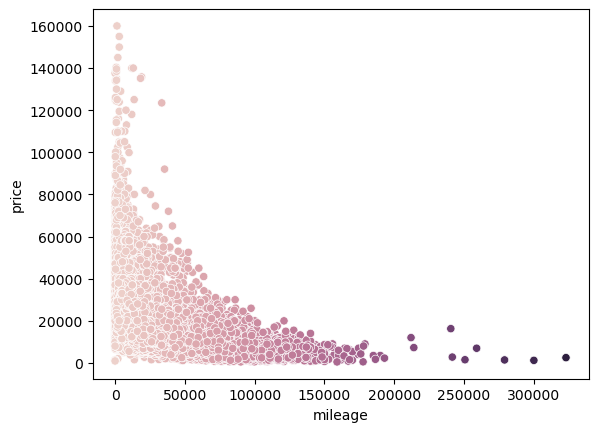

In [285]:
sns.scatterplot(x='mileage', y=TARGET_PRICE, hue='mileage', data=df, legend=False)

<Axes: xlabel='year', ylabel='price'>

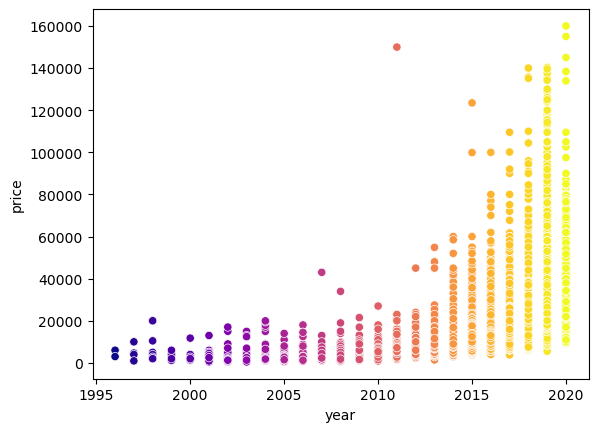

In [286]:
year = 'year'
sns.scatterplot(x=year, y=TARGET_PRICE, data=df, hue=year, palette='plasma', legend=False)

<Axes: xlabel='brand', ylabel='price'>

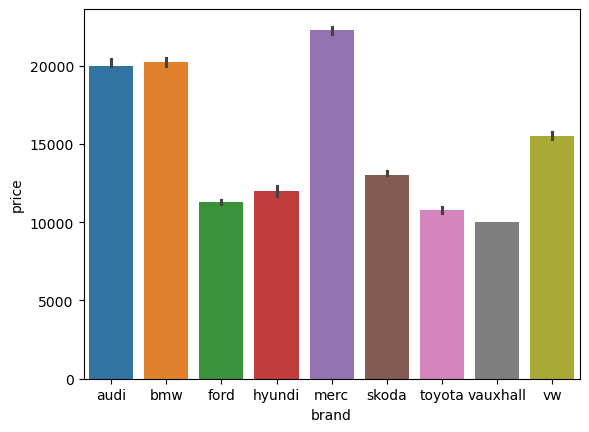

In [287]:
brand = 'brand'
sns.barplot(x= brand, y=TARGET_PRICE, hue=brand, data=df, estimator='median')

<Axes: xlabel='fuelType', ylabel='price'>

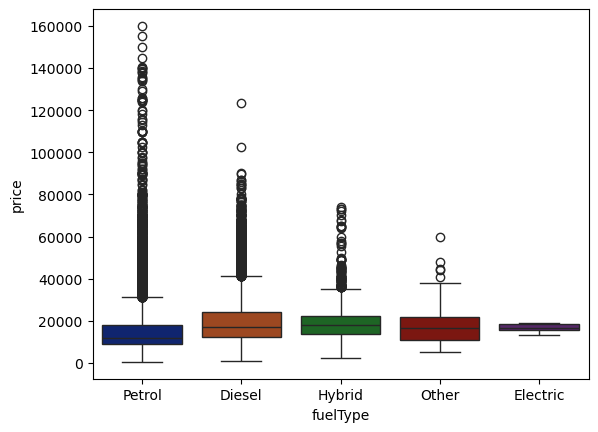

In [288]:
fuel_type = 'fuelType'
sns.boxplot(x=fuel_type, y=TARGET_PRICE, data=df, hue=fuel_type, palette='dark')

In [289]:
df[fuel_type].value_counts()

fuelType
Petrol      53819
Diesel      40338
Hybrid       3033
Other         245
Electric        6
Name: count, dtype: int64

In [290]:
X = df.drop(columns=[TARGET_PRICE])
y = df[TARGET_PRICE]

In [291]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE,
    test_size=0.2
)

In [292]:
print(X_train.shape, X_test.shape)

(77952, 9) (19489, 9)


In [303]:
cat_cols = X.select_dtypes(include=['object']).columns.to_list()
num_cols = X.select_dtypes(include=[np.number]).columns.to_list()
print(cat_cols)
print(num_cols)

['model', 'transmission', 'fuelType', 'brand']
['year', 'mileage', 'tax', 'mpg', 'engineSize']


In [304]:
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])

In [305]:
preprocess

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['model', 'transmission', 'fuelType',
                                  'brand']),
                                ('num', 'passthrough',
                                 ['year', 'mileage', 'tax', 'mpg',
                                  'engineSize'])])

In [306]:
lr_pipe = Pipeline([("preprocess", preprocess), ("model", LinearRegression())])
rf_pipe = Pipeline([("preprocess", preprocess),
                    ("model", RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))])

In [307]:
# Models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}

results = {}
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)

    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)

    results[name] = pipe
    print(name)
    print("  Train R²:", round(r2_score(y_train, train_pred), 4))
    print("  Test R²: ", round(r2_score(y_test, test_pred), 4))
    print("  Test MAE: £", round(mean_absolute_error(y_test, test_pred)))
    print()

Linear Regression
  Train R²: 0.7785
  Test R²:  0.7847
  Test MAE: £ 2860

Random Forest
  Train R²: 0.9939
  Test R²:  0.9641
  Test MAE: £ 1128



In [310]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 4.4 MB/s eta 0:00:003.8 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [312]:
# pip install xgboost   (only if the import fails)
from xgboost import XGBRegressor

xgb_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=6,
                           random_state=RANDOM_STATE, n_jobs=-1))
])
xgb_pipe.fit(X_train, y_train)

train_pred = xgb_pipe.predict(X_train)
test_pred = xgb_pipe.predict(X_test)
print("XGBoost")
print("  Train R²:", round(r2_score(y_train, train_pred), 4))
print("  Test R²: ", round(r2_score(y_test, test_pred), 4))
print("  Test MAE: £", round(mean_absolute_error(y_test, test_pred)))

XGBoost
  Train R²: 0.97
  Test R²:  0.963
  Test MAE: £ 1201
